# Merge OpenAlex parts & describe

Loads every `synbio_openalex_PART_*.txt` file produced by `get_synbio_data.ipynb`,
concatenates them, removes duplicates, sanitizes missing values, and shows
summary statistics. The merged file is saved to `../assets/`.

In [13]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
INPUT_DIR  = os.path.join('..', 'assets', 'openalex_data')
OUTPUT_DIR = os.path.join('..', 'assets')

## 1. Load & concatenate all parts

In [15]:
files = sorted(glob.glob(os.path.join(INPUT_DIR, 'synbio_openalex_PART_*.txt')))
print(f'Found {len(files)} part file(s):')
for f in files:
    print(f'  {os.path.basename(f)}')

parts = [pd.read_csv(f, sep='\t') for f in files]
pubs = pd.concat(parts, ignore_index=True)
print(f'\nTotal rows after concatenation: {len(pubs):,}')

Found 7 part file(s):
  synbio_openalex_PART_1.txt
  synbio_openalex_PART_2.txt
  synbio_openalex_PART_3.txt
  synbio_openalex_PART_4.txt
  synbio_openalex_PART_5.txt
  synbio_openalex_PART_6.txt
  synbio_openalex_PART_7.txt

Total rows after concatenation: 35,016


## 2. Deduplicate & sanitize

In [16]:
before = len(pubs)
pubs.drop_duplicates(subset='id', inplace=True)
pubs.reset_index(drop=True, inplace=True)
print(f'Duplicates removed: {before - len(pubs):,}')
print(f'Unique publications: {len(pubs):,}')

Duplicates removed: 1,388
Unique publications: 33,628


In [17]:
# ── Keep only English articles ────────────────────────────────────────────────
before = len(pubs)
pubs = pubs[pubs['language'] == 'en'].reset_index(drop=True)
print(f'Non-English removed: {before - len(pubs):,}  (remaining: {len(pubs):,})')

# ── Remove articles without abstracts ────────────────────────────────────────
before = len(pubs)
pubs = pubs[pubs['abstract'].notna() & (pubs['abstract'].str.strip() != '')].reset_index(drop=True)
print(f'No-abstract removed: {before - len(pubs):,}  (remaining: {len(pubs):,})')

Non-English removed: 1,031  (remaining: 32,597)
No-abstract removed: 8,395  (remaining: 24,202)


In [18]:
# Fill NaN in string columns with empty strings
str_cols = pubs.select_dtypes(include='object').columns
pubs[str_cols] = pubs[str_cols].fillna('')

# Fill NaN in numeric columns with 0
num_cols = pubs.select_dtypes(include='number').columns
pubs[num_cols] = pubs[num_cols].fillna(0)

print('NaN counts after sanitization:')
print(pubs.isna().sum())

NaN counts after sanitization:
id                  0
doi                 0
title               0
publication_year    0
language            0
type                0
source_id           0
source_name         0
authors             0
institutions        0
countries           0
cited_by_count      0
abstract            0
concepts            0
referenced_works    0
dtype: int64


## 3. Save merged file

In [19]:
output_path = os.path.join(OUTPUT_DIR, 'synbio_openalex.txt')
pubs.to_csv(output_path, sep='\t', index=False)
print(f'Saved {len(pubs):,} records to {output_path}')

Saved 24,202 records to ../assets/synbio_openalex.txt


## 4. Summary statistics

In [20]:
print(f'Shape: {pubs.shape}')
print(f'Columns: {pubs.columns.tolist()}\n')

non_empty = lambda col: (pubs[col].astype(str).str.strip() != '').sum()

for col in ['abstract', 'authors', 'institutions', 'countries', 'concepts', 'referenced_works', 'doi']:
    n = non_empty(col)
    print(f'  {col:20s}  {n:>7,} / {len(pubs):,}  ({n/len(pubs):.1%})')

print(f'\nCitation stats:')
pubs['cited_by_count'].describe()

Shape: (24202, 15)
Columns: ['id', 'doi', 'title', 'publication_year', 'language', 'type', 'source_id', 'source_name', 'authors', 'institutions', 'countries', 'cited_by_count', 'abstract', 'concepts', 'referenced_works']

  abstract               24,202 / 24,202  (100.0%)
  authors                24,007 / 24,202  (99.2%)
  institutions           19,872 / 24,202  (82.1%)
  countries              19,863 / 24,202  (82.1%)
  concepts               24,138 / 24,202  (99.7%)
  referenced_works       24,202 / 24,202  (100.0%)
  doi                    21,365 / 24,202  (88.3%)

Citation stats:


count    24202.000000
mean        31.547765
std         88.211792
min          0.000000
25%          1.000000
50%          8.000000
75%         31.000000
max       3046.000000
Name: cited_by_count, dtype: float64

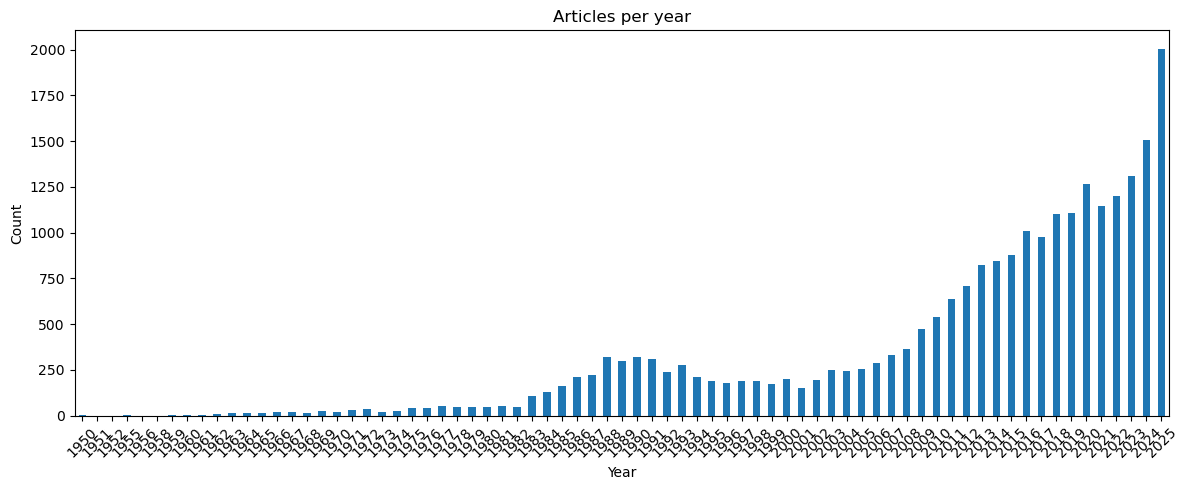

In [21]:
# Articles per year
yearly = pubs['publication_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
yearly.plot(kind='bar', ax=ax)
ax.set_title('Articles per year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
def top_values(col: str, sep: str = '; ', n: int = 20):
    """Explode a semicolon-separated column and show the top-n values."""
    vals = pubs[col].str.split(sep).explode().str.strip()
    vals = vals[vals != '']
    return vals.value_counts().head(n)

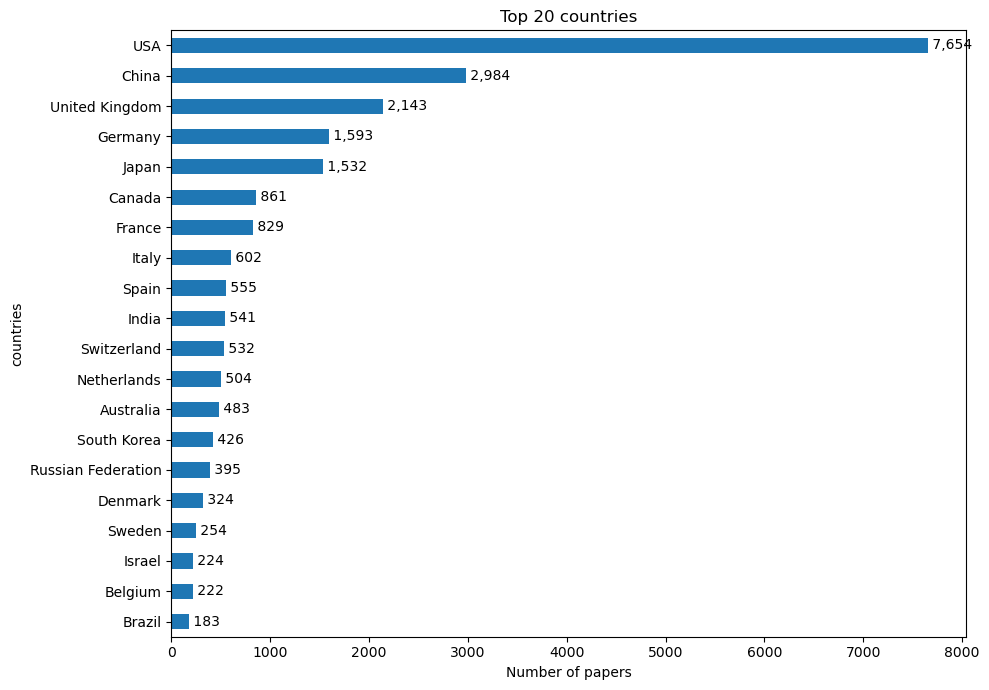

In [23]:
# Top 20 countries
top_countries = top_values('countries')

fig, ax = plt.subplots(figsize=(10, 7))
top_countries.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of papers')
ax.set_title('Top 20 countries')
for i, v in enumerate(top_countries):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

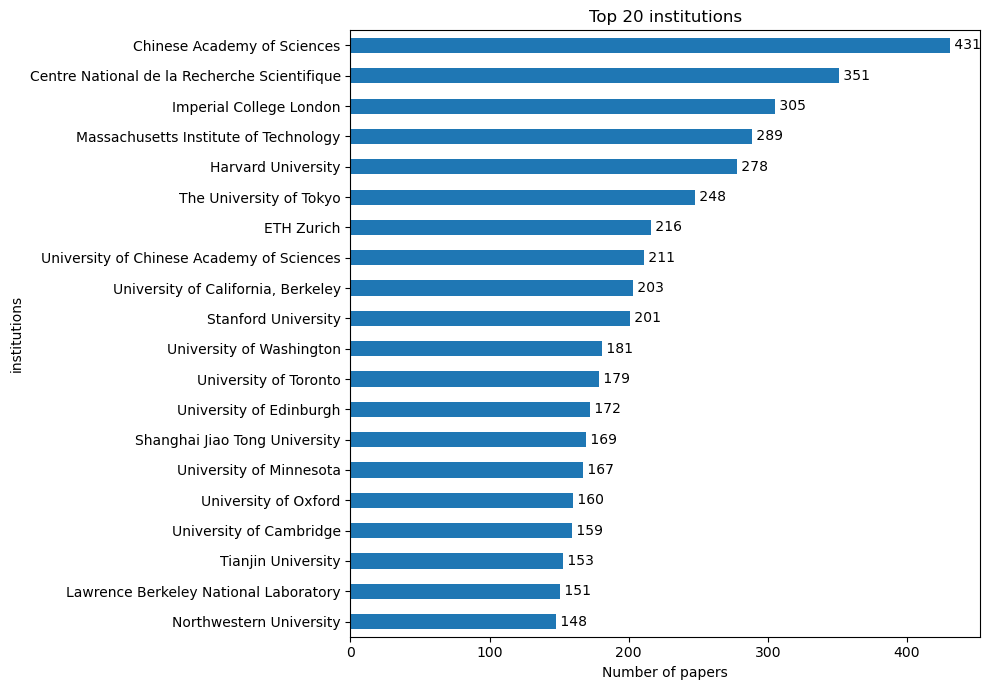

In [24]:
# Top 20 institutions
top_inst = top_values('institutions')

fig, ax = plt.subplots(figsize=(10, 7))
top_inst.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of papers')
ax.set_title('Top 20 institutions')
for i, v in enumerate(top_inst):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

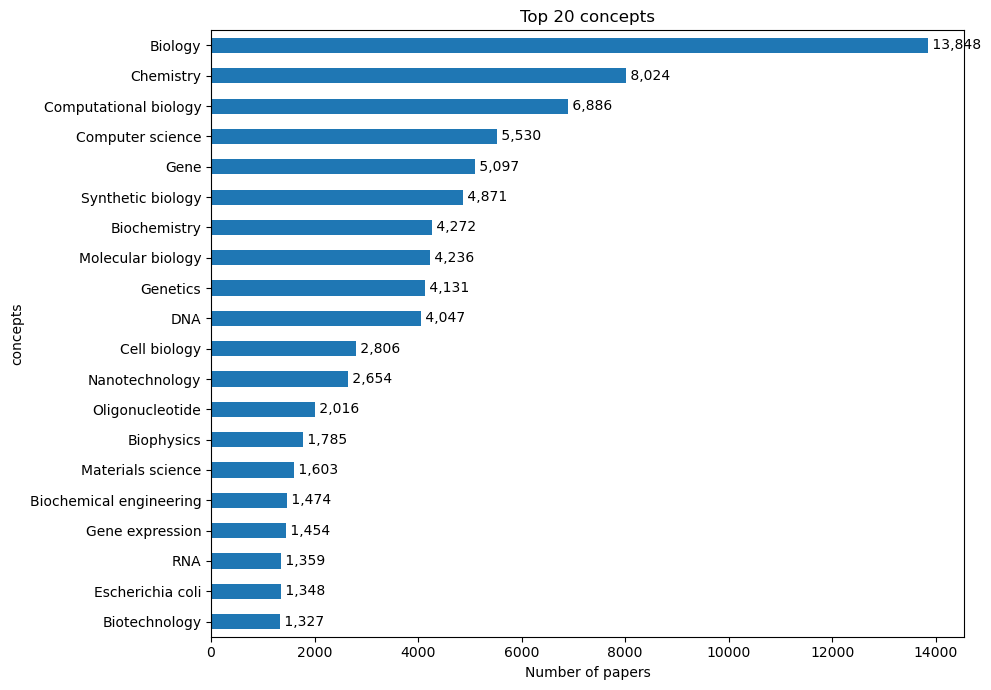

In [25]:
# Top 20 concepts
top_concepts = top_values('concepts')

fig, ax = plt.subplots(figsize=(10, 7))
top_concepts.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of papers')
ax.set_title('Top 20 concepts')
for i, v in enumerate(top_concepts):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()